In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# import zipfile
# import os

# ZIP_PATH = "/content/drive/MyDrive/CE_Dataset/frames_224_32.zip"
# EXTRACT_PATH = "/content/frames_224_32"

# if not os.path.exists(EXTRACT_PATH):
#     with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
#         zip_ref.extractall("/content/")

# print("Extraction complete.")


import os

ZIP_PATH = "/content/drive/MyDrive/CE_Dataset/frames_224_32.zip"
EXTRACT_PATH = "/content/dataset_local" # Keep it simple

if not os.path.exists(EXTRACT_PATH):
    print("🚀 Starting high-speed local extraction...")
    os.makedirs(EXTRACT_PATH, exist_ok=True)
    # Using system unzip with -q (quiet) is faster and prevents browser lag
    !unzip -q {ZIP_PATH} -d {EXTRACT_PATH}
    print("✅ Extraction complete! Your data is now on the local SSD.")
else:
    print("📂 Local dataset already exists. Skipping extraction.")

# Update your data generator path to use the LOCAL path
# Example: TRAIN_DIR = "/content/dataset_local/train"

🚀 Starting high-speed local extraction...
✅ Extraction complete! Your data is now on the local SSD.


In [ ]:
import os
import numpy as np
import pandas as pd
import cv2
import tensorflow as tf

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import (
    TimeDistributed,
    GlobalAveragePooling2D,
    LSTM,
    Bidirectional,
    Dense,
    Dropout,
    Input
)
from tensorflow.keras.models import Model
from tensorflow.keras.utils import Sequence
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


In [ ]:
FRAMES_DIR = "/content/dataset_local" # since folders are directly inside content
IMG_SIZE = 224
NUM_FRAMES = 32
BATCH_SIZE = 4 # we can try differnt parameters
#EPOCHS = 10



In [ ]:
CSV_FILE = "/content/CE_Labels.csv"
df = pd.read_csv(CSV_FILE)


In [ ]:
# Encode labels
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["engagement_label"])

num_classes = len(label_encoder.classes_)

In [ ]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)


In [ ]:
# class VideoSequenceGenerator(Sequence):
#     def __init__(self, dataframe, batch_size):
#         self.df = dataframe.reset_index(drop=True)
#         self.batch_size = batch_size

#     def __len__(self):
#         return int(np.ceil(len(self.df) / self.batch_size))


#     def __getitem__(self, idx):
#         batch_df = self.df.iloc[idx * self.batch_size:(idx + 1) * self.batch_size]
#         X, y = [], []

#         for _, row in batch_df.iterrows():
#             video_folder = os.path.join(FRAMES_DIR, row["video_filename"])
#             all_frames = sorted(os.listdir(video_folder))

#             # --- UNIFORM SAMPLING LOGIC ---
#             total_available = len(all_frames)
#             if total_available >= NUM_FRAMES:
#                 # Spreads 16 frames across the WHOLE folder
#                 indices = np.linspace(0, total_available - 1, NUM_FRAMES).astype(int)
#                 selected_frames = [all_frames[i] for i in indices]
#             else:
#                 selected_frames = all_frames
#             # ------------------------------

#             video_frames = []
#             for frame_name in selected_frames:
#                 frame_path = os.path.join(video_folder, frame_name)
#                 img = cv2.imread(frame_path)
#                 if img is None: continue
#                 img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
#                 img = img / 255.0
#                 video_frames.append(img)

#             while len(video_frames) < NUM_FRAMES:
#                 video_frames.append(np.zeros((IMG_SIZE, IMG_SIZE, 3)))

#             X.append(video_frames)
#             y.append(row["label"])

#         return np.array(X), tf.keras.utils.to_categorical(y, num_classes=3)


import numpy as np
import cv2
import os
import tensorflow as tf
from tensorflow.keras.utils import Sequence

class VideoSequenceGenerator(Sequence):
    def __init__(self, dataframe, batch_size, frames_dir):
        self.df = dataframe.reset_index(drop=True)
        self.batch_size = batch_size
        self.frames_dir = frames_dir

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, idx):
        batch_df = self.df.iloc[idx * self.batch_size:(idx + 1) * self.batch_size]
        X, y = [], []

        for _, row in batch_df.iterrows():
            # Use the local path passed in __init__
            video_folder = os.path.join(self.frames_dir, str(row["video_filename"]))

            try:
                all_frames = sorted(os.listdir(video_folder))
            except (FileNotFoundError, NotADirectoryError):
                continue

            total_available = len(all_frames)
            if total_available >= NUM_FRAMES:
                indices = np.linspace(0, total_available - 1, NUM_FRAMES).astype(int)
                selected_frames = [all_frames[i] for i in indices]
            else:
                selected_frames = all_frames

            video_frames = []
            for frame_name in selected_frames:
                frame_path = os.path.join(video_folder, frame_name)
                img = cv2.imread(frame_path)
                if img is None: continue

                # COLOR CORRECTION: EfficientNet expects RGB
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                # PREPROCESSING: Official EfficientNet scaling
                img = tf.keras.applications.efficientnet.preprocess_input(img)
                video_frames.append(img)

            # Padding for short videos
            while len(video_frames) < NUM_FRAMES:
                video_frames.append(np.zeros((IMG_SIZE, IMG_SIZE, 3)))

            X.append(video_frames)
            y.append(row["label"])

        return np.array(X, dtype='float32'), tf.keras.utils.to_categorical(y, num_classes=3)

In [ ]:
# The updated path based on your screenshot
LOCAL_DATA_DIR = "/content/dataset_local"

train_gen = VideoSequenceGenerator(
    dataframe=train_df,
    batch_size=BATCH_SIZE,
    frames_dir=LOCAL_DATA_DIR
)

val_gen = VideoSequenceGenerator(
    dataframe=val_df,
    batch_size=BATCH_SIZE,
    frames_dir=LOCAL_DATA_DIR
)

print(f"Generators ready. Path confirmed: {LOCAL_DATA_DIR}")

Generators ready. Path confirmed: /content/dataset_local


In [ ]:
# train_gen = VideoSequenceGenerator(train_df, BATCH_SIZE)
# val_gen = VideoSequenceGenerator(val_df, BATCH_SIZE)


In [ ]:
# from tensorflow.keras.layers import Input, TimeDistributed, GlobalAveragePooling2D, Bidirectional, LSTM, Dropout, Dense, SpatialDropout3D
# from tensorflow.keras.applications import EfficientNetB0
# from tensorflow.keras.regularizers import l2

# def build_efficientnet_bilstm_regularized(input_shape=(32, 128, 128, 3), num_classes=3):
#     # 1. Load Base
#     base_cnn = EfficientNetB0(weights='imagenet', include_top=False, input_shape=input_shape[1:])
#     base_cnn.trainable = True

#     video_input = Input(shape=input_shape)

#     # 2. Add Spatial Dropout
#     # This drops entire feature maps across the time dimension,
#     # forcing the model not to rely on specific "pixels" but on general shapes.
#     x = SpatialDropout3D(0.2)(video_input)

#     # 3. Spatial Feature Extraction
#     x = TimeDistributed(base_cnn)(x)
#     x = TimeDistributed(GlobalAveragePooling2D())(x)

#     # 4. Temporal Feature Extraction with L2 Regularization
#     # kernel_regularizer prevents the LSTM weights from becoming too large/complex
#     x = Bidirectional(LSTM(64,
#                            return_sequences=False,
#                            kernel_regularizer=l2(0.01),
#                            recurrent_regularizer=l2(0.01)))(x)

#     # 5. Bottleneck Regularization
#     x = Dense(32, activation='relu', kernel_regularizer=l2(0.01))(x)
#     x = Dropout(0.5)(x)

#     # 6. Output Layer
#     outputs = Dense(num_classes, activation='softmax')(x)

#     model = Model(video_input, outputs)

#     model.compile(
#         optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # Lower LR for fine-tuning
#         loss='categorical_crossentropy',
#         metrics=['accuracy']
#     )

#     return model

# eff_model = build_efficientnet_bilstm_regularized()


import tensorflow as tf
from tensorflow.keras.layers import Input, TimeDistributed, GlobalAveragePooling2D, Bidirectional, LSTM, Dropout, Dense, SpatialDropout3D
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Model

def build_efficientnet_bilstm_updated(input_shape=(32, 128, 128, 3), num_classes=3):
    # 1. Load Base with Global Regularization
    # We unfreeze the top layers to let it learn classroom-specific features
    base_cnn = EfficientNetB0(weights='imagenet', include_top=False, input_shape=input_shape[1:])

    # UNFREEZE: Allow the model to specialize
    base_cnn.trainable = True
    # Freeze the first 150 layers (generic shapes) and fine-tune the rest (specific behaviors)
    for layer in base_cnn.layers[:-50]:
        layer.trainable = False

    video_input = Input(shape=input_shape)

    # 2. Spatial Dropout (Critical for small datasets)
    x = SpatialDropout3D(0.3)(video_input)

    # 3. Spatial Feature Extraction
    x = TimeDistributed(base_cnn)(x)
    x = TimeDistributed(GlobalAveragePooling2D())(x)

    # 4. Enhanced Temporal Extraction
    # Increased LSTM units to 128 to handle the complexity of 32 frames
    x = Bidirectional(LSTM(128,
                           return_sequences=False,
                           kernel_regularizer=l2(0.005),
                           recurrent_regularizer=l2(0.005)))(x)

    # 5. Bottleneck with higher Dropout
    # Increasing dropout to 0.5 to stop the 80% Training / 50% Validation gap
    x = Dense(64, activation='relu', kernel_regularizer=l2(0.005))(x)
    x = Dropout(0.5)(x)

    # 6. Final Output
    outputs = Dense(num_classes, activation='softmax', dtype='float32')(x)

    model = Model(video_input, outputs)

    # 7. Ultra-Low Learning Rate for Fine-Tuning
    # 1e-6 is safer when the backbone is unfrozen
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Clear RAM before building
tf.keras.backend.clear_session()
eff_model = build_efficientnet_bilstm_updated()
eff_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print(eff_model.input_shape)

(None, 32, 128, 128, 3)


In [ ]:
# callbacks = [
#     # 1. EarlyStopping: Monitor LOSS instead of Accuracy
#     tf.keras.callbacks.EarlyStopping(
#         monitor='val_loss',      # Switch to val_loss for EfficientNet
#         patience=12,
#         restore_best_weights=True,
#         verbose=1
#     ),
#     # 2. ReduceLROnPlateau: Keep as is, but watch the patience
#     tf.keras.callbacks.ReduceLROnPlateau(
#         monitor='val_loss',
#         factor=0.2,              # Steeper cut (0.2 instead of 0.5) for EfficientNet
#         patience=4,              # Slightly faster response
#         min_lr=1e-7,
#         verbose=1
#     )
# ]

callbacks = [
    # 1. EarlyStopping: Increase patience slightly
    # Fine-tuning is slow; sometimes the loss stays flat before it drops
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,             # Increased from 12 to give fine-tuning room
        restore_best_weights=True,
        verbose=1
    ),

    # 2. ReduceLROnPlateau: Adjust for the low starting LR
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,              # 0.2 might be too aggressive when starting at 1e-6
        patience=5,              # Wait 5 epochs before cutting
        min_lr=1e-8,             # Lower the floor to give it more "steps"
        verbose=1
    ),

    # 3. ModelCheckpoint: (HIGHLY RECOMMENDED)
    # Since 32 frames + Unfrozen backbone is RAM-heavy,
    # save your best model to a file in case Colab crashes.
    tf.keras.callbacks.ModelCheckpoint(
        'best_effnet_32f.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

In [ ]:
#newly added for class weights

from sklearn.utils import class_weight

# 1. Get the actual labels from your training dataframe
y_train = train_df["label"].values

# 2. Calculate balanced weights
# This will give High and Low a weight of ~1.3 and Medium ~0.6
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# 3. Create the dictionary Keras expects
cw_dict = dict(enumerate(weights))

print(f"Mapping: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")
print(f"Class Weights: {cw_dict}")

Mapping: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
Class Weights: {0: np.float64(1.3031550068587106), 1: np.float64(1.3532763532763532), 2: np.float64(0.6694855532064834)}


In [ ]:
history = eff_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    class_weight=cw_dict,
    callbacks=callbacks,
    verbose=1  # This ensures we see the progress bar
)

# history = model.fit(
#     train_gen,
#     validation_data=val_gen,
#     epochs=EPOCHS
# )


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 992s 2s/step - accuracy: 0.3445 - loss: 11.3863 - val_accuracy: 0.4076 - val_loss: 11.0292 - learning_rate: 1.0000e-05
Epoch 2/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 321s 1s/step - accuracy: 0.3457 - loss: 10.9497 - val_accuracy: 0.4748 - val_loss: 10.6292 - learning_rate: 1.0000e-05
Epoch 3/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 322s 1s/step - accuracy: 0.4020 - loss: 10.5547 - val_accuracy: 0.4538 - val_loss: 10.2580 - learning_rate: 1.0000e-05
Epoch 4/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 320s 1s/step - accuracy: 0.4463 - loss: 10.1857 - val_accuracy: 0.4370 - val_loss: 9.9051 - learning_rate: 1.0000e-05
Epoch 5/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 321s 1s/step - accuracy: 0.4303 - loss: 9.8212 - val_accuracy: 0.4790 - val_loss: 9.5431 - learning_rate: 1.0000e-05
Epoch 6/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 321s 1s/step - accuracy: 0.4384 - loss: 9.4573 - val_accuracy: 0.4832 - val_loss: 9.1962 - learning_rate: 1.0000e-05
Epoch 7/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 321s 1s/ste

In [ ]:
preds = eff_model.predict(val_gen, verbose=0)

y_pred = np.argmax(preds, axis=1)
y_true = val_df["label"].values

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_
))


In [ ]:
# Save the entire model (architecture + weights + optimizer state)
eff_model.save('sampled_efficientnet_model2_63acc.h5')

In [ ]:
from google.colab import files
files.download('sampled_mobnet_model2_63acc.h5')

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt

# Match these exactly to your training settings
IMG_SIZE = 224
NUM_FRAMES = 32
# Assuming your label encoder was alphabetical: 0:High, 1:Low, 2:Medium
class_names = ['High', 'Low', 'Medium']


In [ ]:
print(eff_model.input_shape)

In [ ]:
#attentionNet

In [ ]:
from sklearn.model_selection import train_test_split

# 80% for training, 20% for validation
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['engagement_label'])

print(f"Total Videos: {len(df)}")
print(f"Training on: {len(train_df)}")
print(f"Validating on: {len(val_df)}")

Total Videos: 1188
Training on: 950
Validating on: 238


In [ ]:
import os
import numpy as np
import pandas as pd
import cv2
import tensorflow as tf

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import (
    TimeDistributed,
    GlobalAveragePooling2D,
    LSTM,
    Bidirectional,
    Dense,
    Dropout,
    Input
)
from tensorflow.keras.models import Model
from tensorflow.keras.utils import Sequence
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

class VideoSequenceGenerator(Sequence):
    def __init__(self, dataframe, batch_size):
        self.df = dataframe.reset_index(drop=True)
        self.batch_size = batch_size

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))


    def __getitem__(self, idx):
        batch_df = self.df.iloc[idx * self.batch_size:(idx + 1) * self.batch_size]
        X, y = [], []

        for _, row in batch_df.iterrows():
            video_folder = os.path.join(FRAMES_DIR, row["video_filename"])
            all_frames = sorted(os.listdir(video_folder))

            # --- UNIFORM SAMPLING LOGIC ---
            total_available = len(all_frames)
            if total_available >= NUM_FRAMES:
                # Spreads 16 frames across the WHOLE folder
                indices = np.linspace(0, total_available - 1, NUM_FRAMES).astype(int)
                selected_frames = [all_frames[i] for i in indices]
            else:
                selected_frames = all_frames
            # ------------------------------

            video_frames = []
            for frame_name in selected_frames:
                frame_path = os.path.join(video_folder, frame_name)
                img = cv2.imread(frame_path)
                if img is None: continue
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                img = img / 255.0
                video_frames.append(img)

            while len(video_frames) < NUM_FRAMES:
                video_frames.append(np.zeros((IMG_SIZE, IMG_SIZE, 3)))

            X.append(video_frames)
            y.append(row["label"])

        return np.array(X), tf.keras.utils.to_categorical(y, num_classes=3)

In [ ]:
# # # 1. Define these as GLOBAL variables (the Generator looks for these exact names)
# FRAMES_DIR = "/vol/fastdata/daisee_A/CE/frames_224_32" # Update this!
# IMG_SIZE = 224
# NUM_FRAMES = 32

# 2. Split your data (ensure labels are 0, 1, 2)
# If your CSV labels are "High", "Low", etc., map them to 0, 1, 2 first
#train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

# 3. Initialize without the extra directory argument
train_gen = VideoSequenceGenerator(train_df, batch_size=4)
val_gen = VideoSequenceGenerator(val_df, batch_size=4)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

def build_stable_attention_net():
    video_input = layers.Input(shape=(NUM_FRAMES, IMG_SIZE, IMG_SIZE, 3))

    # 1. THE EYES (Standard MobileNetV2 - stick to what worked!)
    base_model = tf.keras.applications.MobileNetV2(
        weights="imagenet", include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base_model.trainable = False # Keep it frozen first to stabilize

    x = layers.TimeDistributed(base_model)(video_input)
    x = layers.TimeDistributed(layers.GlobalAveragePooling2D())(x)

    # 2. THE STABLE ATTENTION (Custom Temporal Attention)
    # Instead of MultiHeadAttention, we use a simple trainable weight per frame
    score = layers.Dense(1, activation='tanh')(x)
    attention_weights = layers.Activation('softmax')(score) # Weights for each of the 32 frames

    # Multiply frames by their importance
    context = layers.Multiply()([x, attention_weights])

    # 3. THE REASONING
    x = layers.Bidirectional(layers.LSTM(64))(context)

    # 4. THE OUTPUT
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(3, activation="softmax")(x)

    return Model(video_input, output)

# --- CLEAN BUILD ---
tf.keras.backend.clear_session()
model = build_stable_attention_net()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,          # Stops if no improvement for 5 epochs
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,          # Drops learning rate if stuck
        min_lr=1e-7
    )
]

In [ ]:
from sklearn.utils import class_weight
import numpy as np

# Ensure your labels are already mapped to 0, 1, 2
# This looks at your training data to see which class is rare
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['engagement_label']),
    y=train_df['engagement_label']
)

# Convert to the dictionary format Keras expects: {0: weight, 1: weight, 2: weight}
class_weights_dict = dict(enumerate(weights))

print("Class Weights Applied:", class_weights_dict)

Class Weights Applied: {0: np.float64(1.3031550068587106), 1: np.float64(1.3532763532763532), 2: np.float64(0.6694855532064834)}


In [ ]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50, # EarlyStopping will likely stop it around 15-20
    class_weight=class_weights_dict, # <--- CRITICAL
    callbacks=callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


238/238 ━━━━━━━━━━━━━━━━━━━━ 513s 2s/step - accuracy: 0.3408 - loss: 1.1370 - val_accuracy: 0.4748 - val_loss: 1.0253 - learning_rate: 1.0000e-04
Epoch 2/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 341s 1s/step - accuracy: 0.4569 - loss: 1.0151 - val_accuracy: 0.4160 - val_loss: 1.0451 - learning_rate: 1.0000e-04
Epoch 3/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 344s 1s/step - accuracy: 0.4797 - loss: 0.9784 - val_accuracy: 0.4622 - val_loss: 1.0280 - learning_rate: 1.0000e-04
Epoch 4/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 351s 1s/step - accuracy: 0.4577 - loss: 0.9801 - val_accuracy: 0.4748 - val_loss: 1.0021 - learning_rate: 1.0000e-04
Epoch 5/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 359s 2s/step - accuracy: 0.5227 - loss: 0.9169 - val_accuracy: 0.4916 - val_loss: 0.9979 - learning_rate: 1.0000e-04
Epoch 6/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 350s 1s/step - accuracy: 0.5080 - loss: 0.8986 - val_accuracy: 0.5630 - val_loss: 0.9301 - learning_rate: 1.0000e-04
Epoch 7/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 338s 1s/step - accuracy: 0.52


📊 Generating Final Report...


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (4, 32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


59/60 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


60/60 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

         Low       0.50      0.62      0.55        61
      Medium       0.51      0.61      0.55        59
        High       0.62      0.47      0.54       118

    accuracy                           0.55       238
   macro avg       0.54      0.57      0.55       238
weighted avg       0.56      0.55      0.55       238



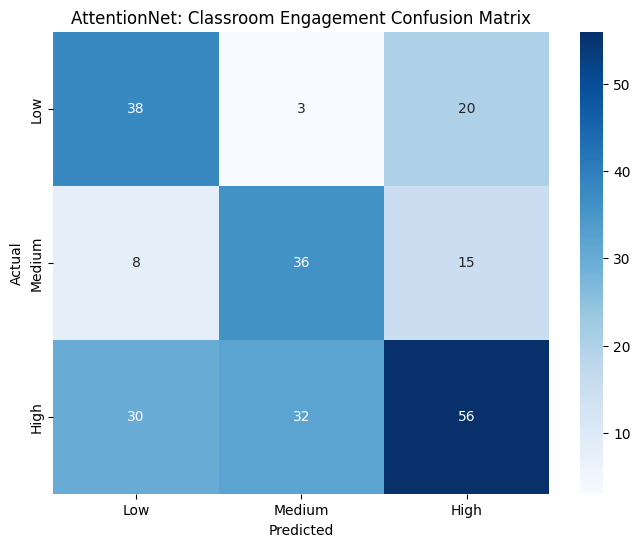

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("\n📊 Generating Final Report...")

# 1. Get Predictions
y_pred_probs = model.predict(val_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Get True Labels from the Generator
y_true = []
# We iterate through the generator to get the labels exactly as they were served
for i in range(len(val_gen)):
    _, labels = val_gen[i]
    y_true.extend(np.argmax(labels, axis=1))

y_true = np.array(y_true)

# 3. Print Classification Report
target_names = ['Low', 'Medium', 'High']
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, target_names=target_names))

# 4. Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('AttentionNet: Classroom Engagement Confusion Matrix')
plt.show()

In [ ]:
# 1. Save the entire model (Architecture + Weights + Optimizer state)
model.save('AttentionNet_Classroom_Final.keras')

# 2. Save just the weights (Useful if you want to load them into a different script)
model.save_weights('AttentionNet_Weights_Only.h5')

print("✅ Model saved successfully as 'AttentionNet_Classroom_Final.keras'")

ValueError: The filename must end in `.weights.h5`. Received: filepath=AttentionNet_Weights_Only.h5

In [ ]:
from google.colab import files

# This will download the file directly to your 'Downloads' folder on your computer
files.download('AttentionNet_Classroom_Final.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Load your saved model
model = tf.keras.models.load_model('AttentionNet_Classroom_Final.keras')

# Unfreeze the last 50 layers of the backbone
for layer in model.layers:
    if "mobilenet" in layer.name or "efficientnet" in layer.name:
        layer.trainable = True
        # Keep the bottom layers frozen to prevent "forgetting"
        for sub_layer in layer.layers[:-50]:
            sub_layer.trainable = False

# Re-compile with a TINY learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train for just 5-10 more epochs
model.fit(train_gen, validation_data=val_gen, epochs=10, class_weight=class_weights_dict)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


238/238 ━━━━━━━━━━━━━━━━━━━━ 527s 2s/step - accuracy: 0.6759 - loss: 0.6442 - val_accuracy: 0.5504 - val_loss: 0.8824
Epoch 2/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 332s 1s/step - accuracy: 0.6383 - loss: 0.7303 - val_accuracy: 0.5546 - val_loss: 0.8823
Epoch 3/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 338s 1s/step - accuracy: 0.6615 - loss: 0.6953 - val_accuracy: 0.5546 - val_loss: 0.8834
Epoch 4/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 335s 1s/step - accuracy: 0.6727 - loss: 0.6799 - val_accuracy: 0.5546 - val_loss: 0.8829
Epoch 5/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 396s 1s/step - accuracy: 0.6619 - loss: 0.6767 - val_accuracy: 0.5546 - val_loss: 0.8837
Epoch 6/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 331s 1s/step - accuracy: 0.6740 - loss: 0.6486 - val_accuracy: 0.5546 - val_loss: 0.8830
Epoch 7/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 332s 1s/step - accuracy: 0.6663 - loss: 0.6408 - val_accuracy: 0.5462 - val_loss: 0.8836
Epoch 8/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 332s 1s/step - accuracy: 0.6624 - loss: 0.6640 - val_accuracy: 0.550


📊 Generating Final Report...


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (4, 32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


60/60 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

         Low       0.51      0.61      0.56        61
      Medium       0.52      0.64      0.58        59
        High       0.61      0.48      0.54       118

    accuracy                           0.55       238
   macro avg       0.55      0.58      0.56       238
weighted avg       0.56      0.55      0.55       238



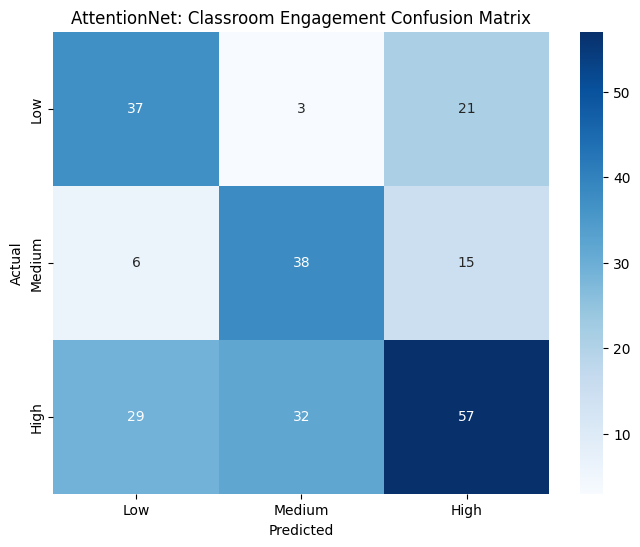

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("\n📊 Generating Final Report...")

# 1. Get Predictions
y_pred_probs = model.predict(val_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Get True Labels from the Generator
y_true = []
# We iterate through the generator to get the labels exactly as they were served
for i in range(len(val_gen)):
    _, labels = val_gen[i]
    y_true.extend(np.argmax(labels, axis=1))

y_true = np.array(y_true)

# 3. Print Classification Report
target_names = ['Low', 'Medium', 'High']
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, target_names=target_names))

# 4. Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('AttentionNet: Classroom Engagement Confusion Matrix')
plt.show()

In [ ]:
# Use a very small learning rate to avoid "breaking" what it already knows
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

# Train for 5 more epochs
history_final = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    class_weight=class_weights_dict
)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


238/238 ━━━━━━━━━━━━━━━━━━━━ 525s 2s/step - accuracy: 0.6723 - loss: 0.7713 - val_accuracy: 0.5546 - val_loss: 0.9444
Epoch 2/5
238/238 ━━━━━━━━━━━━━━━━━━━━ 337s 1s/step - accuracy: 0.6566 - loss: 0.7637 - val_accuracy: 0.5546 - val_loss: 0.9431
Epoch 3/5
238/238 ━━━━━━━━━━━━━━━━━━━━ 329s 1s/step - accuracy: 0.6547 - loss: 0.7806 - val_accuracy: 0.5588 - val_loss: 0.9419
Epoch 4/5
238/238 ━━━━━━━━━━━━━━━━━━━━ 328s 1s/step - accuracy: 0.6527 - loss: 0.7902 - val_accuracy: 0.5504 - val_loss: 0.9410
Epoch 5/5
238/238 ━━━━━━━━━━━━━━━━━━━━ 328s 1s/step - accuracy: 0.6662 - loss: 0.7677 - val_accuracy: 0.5420 - val_loss: 0.9396



📊 Generating Final Report...


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (4, 32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


60/60 ━━━━━━━━━━━━━━━━━━━━ 169s 2s/step

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

         Low       0.51      0.61      0.55        61
      Medium       0.51      0.61      0.55        59
        High       0.60      0.47      0.53       118

    accuracy                           0.54       238
   macro avg       0.54      0.56      0.54       238
weighted avg       0.55      0.54      0.54       238



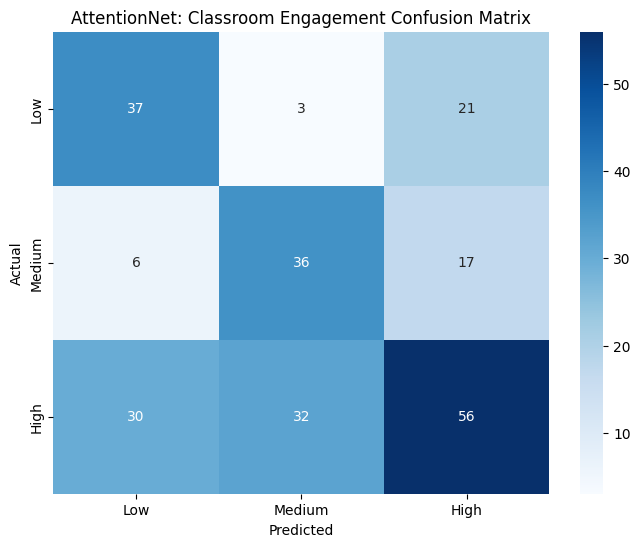

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("\n📊 Generating Final Report...")

# 1. Get Predictions
y_pred_probs = model.predict(val_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Get True Labels from the Generator
y_true = []
# We iterate through the generator to get the labels exactly as they were served
for i in range(len(val_gen)):
    _, labels = val_gen[i]
    y_true.extend(np.argmax(labels, axis=1))

y_true = np.array(y_true)

# 3. Print Classification Report
target_names = ['Low', 'Medium', 'High']
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, target_names=target_names))

# 4. Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('AttentionNet: Classroom Engagement Confusion Matrix')
plt.show()

In [ ]:
#extract 64 frames

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

# Define your save path
SAVE_PATH = '/content/drive/MyDrive/frames_224_64'

if not os.path.exists(SAVE_PATH):
    os.makedirs(SAVE_PATH)
    print(f"Created folder: {SAVE_PATH}")

Mounted at /content/drive


In [ ]:
import cv2
import numpy as np
from tqdm import tqdm

def save_64_frames_to_drive(video_path, video_name):
    # Create a subfolder for this specific video
    video_folder = os.path.join(SAVE_PATH, video_name)
    if not os.path.exists(video_folder):
        os.makedirs(video_folder)

    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames < 64:
        print(f"Warning: {video_name} only has {total_frames} frames. Sampling with repetition.")

    # Calculate 64 equidistant indices
    indices = np.linspace(0, total_frames - 1, 64).astype(int)

    for i, idx in enumerate(indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        success, frame = cap.read()

        if success:
            # Resize to your model's input size
            frame_resized = cv2.resize(frame, (224, 224))
            # Save as frame_00.jpg, frame_01.jpg, etc.
            frame_name = os.path.join(video_folder, f"frame_{i:02d}.jpg")
            cv2.imwrite(frame_name, frame_resized)

    cap.release()

# --- RUN THE EXTRACTION ---
# Replace 'your_video_folder' with the path to your raw MP4s
video_files = [f for f in os.listdir('/content/CE_Dataset/CE_Dataset') if f.endswith('.mp4')]

for v_file in tqdm(video_files, desc="Extracting Frames"):
    path = os.path.join('your_video_folder', v_file)
    name = os.path.splitext(v_file)[0]
    save_64_frames_to_drive(path, name)

print(f"\n✅ All frames saved to Google Drive in: {SAVE_PATH}")

Extracting Frames:   4%|▎         | 44/1188 [00:00<00:05, 201.27it/s]

Extracting Frames:   8%|▊         | 99/1188 [00:00<00:04, 247.31it/s]

Extracting Frames:  10%|█         | 124/1188 [00:00<00:04, 215.82it/s]

Extracting Frames:  14%|█▍        | 170/1188 [00:00<00:04, 220.12it/s]

Extracting Frames:  19%|█▉        | 224/1188 [00:01<00:04, 219.00it/s]

...

Extracting Frames:  88%|████████▊ | 1051/1188 [00:05<00:00, 224.12it/s]

Extracting Frames:  93%|█████████▎| 1100/1188 [00:05<00:00, 224.39it/s]

Extracting Frames:  97%|█████████▋| 1152/1188 [00:05<00:00, 230.97it/s]

Extracting Frames: 100%|██████████| 1188/1188 [00:05<00:00, 208.34it/s]


✅ All frames saved to Google Drive in: /content/drive/MyDrive/frames_224_64


In [ ]:
import os
import cv2

# Test one of your "failed" files
test_file = '/content/CE_Dataset/CE_Dataset/431_4300_4310.mp4' # Update this path!

cap = cv2.VideoCapture(test_file)
if not cap.isOpened():
    print("❌ OpenCV cannot open the file. Check the path or file extension.")
else:
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"✅ File opened. Frame count: {total}")
cap.release()

✅ File opened. Frame count: 300


In [ ]:
import cv2
import numpy as np
import os
from tqdm import tqdm
import time

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

ZIP_PATH = "/content/drive/MyDrive/CE_Dataset/CE_Dataset.zip"
EXTRACT_PATH = "/content/CE_Dataset"

if not os.path.exists(EXTRACT_PATH):
    print("Unzipping dataset...")
    !unzip -q "$ZIP_PATH" -d "$EXTRACT_PATH"

def extract_and_save(video_path, video_name, save_root):
    video_folder = os.path.join(save_root, video_name)

    cap = cv2.VideoCapture(video_path)
    # Give the stream a half-second to "warm up"
    time.sleep(0.1)

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        # One last attempt to get the frame count
        cap.release()
        cap = cv2.VideoCapture(video_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total_frames <= 0:
            return False # Truly broken

    if not os.path.exists(video_folder):
        os.makedirs(video_folder)

    # Uniformly pick 64 indices
    indices = np.linspace(0, total_frames - 1, 64).astype(int)

    for i, idx in enumerate(indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        success, frame = cap.read()
        if success:
            frame_resized = cv2.resize(frame, (224, 224))
            # Save as frame_00.jpg ... frame_63.jpg
            cv2.imwrite(os.path.join(video_folder, f"frame_{i:02d}.jpg"), frame_resized)
        else:
            # If a specific frame fails, we grab the previous one to keep 64 total
            if i > 0:
                prev_frame = os.path.join(video_folder, f"frame_{i-1:02d}.jpg")
                # (Logic to copy previous frame can go here if needed)

    cap.release()
    return True

# --- EXECUTION BLOCK ---
# 1. Update these two paths!
INPUT_VIDEOS_DIR = '/content/CE_Dataset/CE_Dataset'
OUTPUT_FRAMES_DIR = '/content/drive/MyDrive/frames_224_64'

all_videos = [f for f in os.listdir(INPUT_VIDEOS_DIR) if f.lower().endswith(('.mp4', '.avi', '.mov'))]

for v_file in tqdm(all_videos, desc="Processing Videos"):
    v_path = os.path.join(INPUT_VIDEOS_DIR, v_file)
    v_name = os.path.splitext(v_file)[0]

    success = extract_and_save(v_path, v_name, OUTPUT_FRAMES_DIR)
    if not success:
        print(f"⚠️ Failed to read: {v_file}")

print("\n🚀 Processing Complete! Check your 'frames_224_64' folder.")

Unzipping dataset...


Processing Videos:  13%|█▎        | 158/1188 [3:02:31<19:49:51, 69.31s/it]


KeyboardInterrupt: 

In [ ]:
import cv2
import numpy as np
import os
from tqdm import tqdm

# 1. SET LOCAL PATHS (FAST)
LOCAL_INPUT_DIR = '/content/CE_Dataset/CE_Dataset' # Unzip your videos here first!
LOCAL_OUTPUT_DIR = '/content/drive/MyDrive/frames_224_64'
os.makedirs(LOCAL_OUTPUT_DIR, exist_ok=True)

# 2. THE FAST EXTRACTOR (No time.sleep, no Drive latency)
def fast_extract(video_path, video_name):
    video_folder = os.path.join(LOCAL_OUTPUT_DIR, video_name)
    os.makedirs(video_folder, exist_ok=True)

    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        return False

    indices = np.linspace(0, total_frames - 1, 64).astype(int)

    for i, idx in enumerate(indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        success, frame = cap.read()
        if success:
            frame = cv2.resize(frame, (224, 224))
            cv2.imwrite(os.path.join(video_folder, f"frame_{i:02d}.jpg"), frame)

    cap.release()
    return True

# 3. RUN THE LOOP LOCALLY
all_videos = [f for f in os.listdir(LOCAL_INPUT_DIR) if f.endswith('.mp4')]
for v_file in tqdm(all_videos, desc="High-Speed Extraction"):
    fast_extract(os.path.join(LOCAL_INPUT_DIR, v_file), os.path.splitext(v_file)[0])

# 4. ZIP AND MOVE TO DRIVE (The most important part)
print("📦 Zipping frames...")
!zip -r /content/frames_64_final.zip /content/frames_temp > /dev/null

print("🚀 Moving to Drive...")
!cp /content/frames_64_final.zip /content/drive/MyDrive/
print("✅ Done!")

High-Speed Extraction:   2%|▏         | 24/1188 [29:15<23:38:38, 73.13s/it]


KeyboardInterrupt: 

In [ ]:
import cv2
import os
import numpy as np
from tqdm import tqdm

LOCAL_INPUT_DIR ='/content/CE_Dataset/CE_Dataset'
LOCAL_OUTPUT_DIR = '/content/frames_temp'
os.makedirs(LOCAL_OUTPUT_DIR, exist_ok=True)

def turbo_extract(video_path, video_name):
    video_folder = os.path.join(LOCAL_OUTPUT_DIR, video_name)
    os.makedirs(video_folder, exist_ok=True)

    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        return False

    # Pre-calculate exactly which frame numbers we want
    target_indices = set(np.linspace(0, total_frames - 1, 64).astype(int))

    frame_count = 0
    saved_count = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret or saved_count >= 64:
            break

        if frame_count in target_indices:
            # Only resize and save if it's one of our 64 target frames
            frame = cv2.resize(frame, (224, 224))
            cv2.imwrite(os.path.join(video_folder, f"frame_{saved_count:02d}.jpg"), frame)
            saved_count += 1

        frame_count += 1

    cap.release()
    return True

# Run it
all_videos = [f for f in os.listdir(LOCAL_INPUT_DIR) if f.lower().endswith(('.mp4', '.avi'))]
for v_file in tqdm(all_videos, desc="Turbo Extraction"):
    turbo_extract(os.path.join(LOCAL_INPUT_DIR, v_file), os.path.splitext(v_file)[0])

Turbo Extraction: 100%|██████████| 1188/1188 [1:07:37<00:00,  3.42s/it]


In [ ]:
# The -r flag means 'recursive' (all folders)
# The -q flag means 'quiet' (so it doesn't print 76,000 lines of text)
!zip -rq frames_224_64.zip /content/frames_224_64

In [ ]:
import shutil

# This copies the file from Colab's local disk to your Drive
!cp frames_224_64.zip /content/drive/MyDrive/frames_224_64.zip

print("✅ Zip file successfully moved to Drive!")

✅ Zip file successfully moved to Drive!
